# 🔬 Variational Quantum Eigensolver — Deep Dive

**Series 400 — Quantum Simulation** &nbsp;|&nbsp; Notebook 401

Building on the VQE introduction in Notebook 400, this deep dive covers the
mathematical machinery that makes VQE work in practice: analytical gradient
estimation, molecular Hamiltonian construction, hydrogen dissociation as the
canonical benchmark, ansatz design philosophy, optimizer selection, the barren
plateau problem, and measurement strategies.  We close with a survey of
landmark VQE experiments and open frontiers.

> **Prerequisites** — Notebook 400 (variational principle, basic VQE loop).

In [1]:
import numpy as np
from numpy import pi, kron
from scipy.optimize import minimize
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

SEED = 42
np.random.seed(SEED)

I2 = np.eye(2, dtype=complex)
Xm = np.array([[0, 1], [1, 0]], dtype=complex)
Ym = np.array([[0, -1j], [1j, 0]], dtype=complex)
Zm = np.array([[1, 0], [0, -1]], dtype=complex)

print("Environment ready  |  NumPy", np.__version__)

Environment ready  |  NumPy 2.4.3


## Part I — The Parameter Shift Rule

In Notebook 400 we treated VQE as a black-box optimizer.  Now we open the box.

Most parameterised quantum gates have the form
$U(\theta) = e^{-i\theta G/2}$ where $G$ has eigenvalues $\pm 1$
(e.g.\ $R_y(\theta) = e^{-i\theta Y/2}$).  For such gates the **parameter
shift rule** gives the *exact* partial derivative of the cost function:

$$
\frac{\partial \langle H \rangle}{\partial \theta_k}
= \frac{
    \langle H \rangle_{\theta_k + \pi/2}
  - \langle H \rangle_{\theta_k - \pi/2}
}{2}
$$

This is remarkable: unlike finite differences, which approximate $\partial E /
\partial \theta$ with controllable but nonzero error, the parameter shift rule
is **analytically exact** — no step-size tuning, no truncation error.  The
cost is exactly **2 circuit evaluations per parameter**.

| Method | Exact? | Evaluations/param | Noise-tolerant? |
|--------|--------|-------------------|-----------------|
| Finite difference | No (O(ε²) error) | 2 | Poor |
| Parameter shift | Yes | 2 | Yes (same noise in both) |
| SPSA gradient | No (stochastic) | 2 total | Good |
| Analytic (classical) | Yes | 1 | N/A |

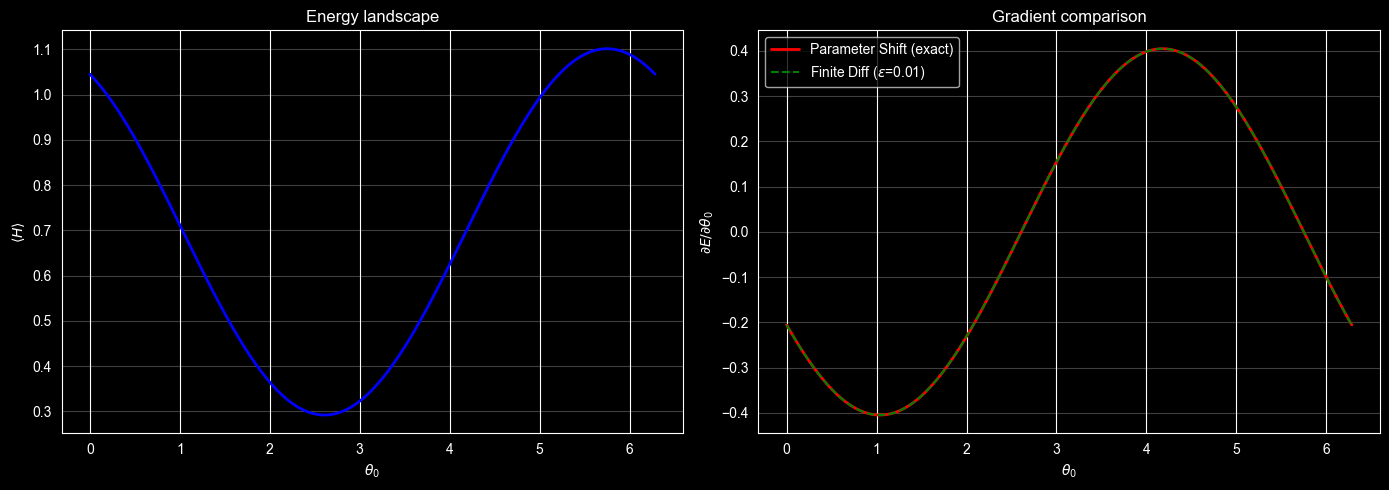

  theta_0: PSR=-0.39917786  FD=-0.39917786  |diff|=6.9e-10
  theta_1: PSR=-1.03343245  FD=-1.03343244  |diff|=2.5e-09
  theta_2: PSR=+0.05927579  FD=+0.05927579  |diff|=2.0e-09

  Parameter shift rule verified (max |PSR - FD| = 2.5e-09)


In [2]:
# --- Parameter Shift Rule demonstration ---
# Circuit: Ry(θ₁)|q0⟩ ⊗ Ry(θ₂)|q1⟩ → CNOT → Rz(θ₃)|q0⟩
# Hamiltonian: H = ZZ + 0.5·ZI − 0.3·IX

H_psr = SparsePauliOp.from_list([("ZZ", 1.0), ("ZI", 0.5), ("IX", -0.3)])

def energy_psr(params):
    qc = QuantumCircuit(2)
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)
    qc.cx(0, 1)
    qc.rz(params[2], 0)
    return float(np.real(Statevector(qc).expectation_value(H_psr)))

def psr_gradient(params, idx):
    s = np.zeros(len(params)); s[idx] = pi / 2
    return (energy_psr(params + s) - energy_psr(params - s)) / 2

def fd_gradient(params, idx, eps=0.01):
    s = np.zeros(len(params)); s[idx] = eps
    return (energy_psr(params + s) - energy_psr(params - s)) / (2 * eps)

# Scan θ₀ with θ₁=0.8, θ₂=0.3 fixed
theta_scan = np.linspace(0, 2 * pi, 200)
fixed = np.array([0.0, 0.8, 0.3])
E_vals = [energy_psr([t, 0.8, 0.3]) for t in theta_scan]
g_psr  = [psr_gradient(np.array([t, 0.8, 0.3]), 0) for t in theta_scan]
g_fd   = [fd_gradient(np.array([t, 0.8, 0.3]), 0) for t in theta_scan]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(theta_scan, E_vals, "b-", lw=2)
ax1.set_xlabel(r"$\theta_0$"); ax1.set_ylabel(r"$\langle H \rangle$")
ax1.set_title("Energy landscape"); ax1.grid(axis="y", alpha=0.25)

ax2.plot(theta_scan, g_psr, "r-", lw=2, label="Parameter Shift (exact)")
ax2.plot(theta_scan, g_fd, "g--", lw=1.5, label=r"Finite Diff ($\varepsilon$=0.01)")
ax2.set_xlabel(r"$\theta_0$"); ax2.set_ylabel(r"$\partial E / \partial \theta_0$")
ax2.set_title("Gradient comparison"); ax2.legend(); ax2.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.savefig("vqe_gradients.png", dpi=150); plt.show()

# Verify PSR is exact for all 3 parameters
p_test = np.array([1.2, 0.8, 0.3])
for k in range(3):
    g_p = psr_gradient(p_test, k)
    g_f = fd_gradient(p_test, k, eps=1e-7)
    print(f"  theta_{k}: PSR={g_p:+.8f}  FD={g_f:+.8f}  |diff|={abs(g_p - g_f):.1e}")

max_diff = max(abs(psr_gradient(p_test, k) - fd_gradient(p_test, k, 1e-7))
               for k in range(3))
assert max_diff < 1e-5, f"PSR mismatch: {max_diff}"
print(f"\n  Parameter shift rule verified (max |PSR - FD| = {max_diff:.1e})")

## Part II — From Molecules to Qubits

To simulate a molecule with VQE we need its **electronic Hamiltonian** as a
sum of Pauli operators.  The pipeline:

1. **Choose a basis set** — e.g.\ STO-3G (minimal Gaussian basis).
2. **Compute molecular integrals** — overlap $S$, kinetic $T$, nuclear
   attraction $V$, electron repulsion $(pq|rs)$ in the atomic orbital basis.
3. **Transform to molecular orbitals** — diagonalise $S$, rotate integrals.
4. **Second-quantise** — express $H$ with creation / annihilation operators
   $a^\dagger_p, a_q$ in the molecular-orbital basis.
5. **Map to qubits** — Jordan–Wigner (Notebook 400) or Bravyi–Kitaev
   transforms fermionic operators into Pauli strings.
6. **Symmetry-reduce** — exploit conserved quantities ($N$, $S_z$) to taper
   qubits and shrink the Hamiltonian.

For **H₂ in STO-3G** (2 spatial orbitals → 4 spin orbitals → 4 JW qubits),
particle-number and spin-parity tapering reduce the problem to **2 qubits**
in the $\{N{=}2,\; S_z{=}0\}$ sector:

$$
H(R) = c_0\, II + c_1\, IZ + c_2\, ZI + c_3\, ZZ + c_4\, YY
$$

where every coefficient $c_k(R)$ depends on the bond distance $R$.  The
$YY$ term encodes the **electron correlation** that Hartree–Fock misses.

In [3]:
# --- H₂ STO-3G Pauli Hamiltonian (2-qubit tapered) ---
# Coefficients computed from STO-3G molecular integrals via
# Jordan-Wigner mapping + N=2, Sz=0 symmetry tapering.
# Reference: O'Malley et al., Phys. Rev. X 6, 031007 (2016)

H2_DATA = [
    # (R_Ang,    c_II,       c_IZ,       c_ZI,       c_ZZ,       c_YY)
    (0.25,  2.1110854, -0.8704718, -0.8704718,  0.0134581, -0.1592336),
    (0.30,  1.0099763, -0.8084769, -0.8084769,  0.0132828, -0.1607748),
    (0.35,  0.7010508, -0.7472469, -0.7472469,  0.0130988, -0.1625286),
    (0.40,  0.4601273, -0.6886545, -0.6886545,  0.0129095, -0.1644697),
    (0.50,  0.1103921, -0.5829255, -0.5829255,  0.0125128, -0.1688219),
    (0.60, -0.1254252, -0.4938739, -0.4938739,  0.0120619, -0.1736793),
    (0.70, -0.2882011, -0.4203323, -0.4203323,  0.0115061, -0.1789457),
    (0.735, -0.3326574, -0.3978202, -0.3978202,  0.0112792, -0.1808750),
    (0.80, -0.4019878, -0.3598536, -0.3598536,  0.0108095, -0.1845681),
    (0.90, -0.4825440, -0.3096986, -0.3096986,  0.0099699, -0.1905092),
    (1.00, -0.5402918, -0.2674558, -0.2674558,  0.0090165, -0.1967244),
    (1.10, -0.5819602, -0.2313370, -0.2313370,  0.0079973, -0.2031526),
    (1.20, -0.6119025, -0.2001428, -0.2001428,  0.0069645, -0.2097187),
    (1.40, -0.6475839, -0.1495400, -0.1495400,  0.0050329, -0.2229444),
    (1.60, -0.6627715, -0.1112931, -0.1112931,  0.0034496, -0.2358205),
    (1.80, -0.6665037, -0.0824013, -0.0824013,  0.0022658, -0.2479343),
    (2.00, -0.6641799, -0.0606232, -0.0606232,  0.0014317, -0.2590549),
    (2.50, -0.6492656, -0.0271328, -0.0271328,  0.0003775, -0.2821257),
    (2.85, -0.6381851, -0.0147844, -0.0147844,  0.0001242, -0.2945739),
]

def h2_hamiltonian(row):
    R, cII, cIZ, cZI, cZZ, cYY = row
    return SparsePauliOp.from_list([
        ("II", cII), ("IZ", cIZ), ("ZI", cZI), ("ZZ", cZZ), ("YY", cYY)
    ])

# Verify at equilibrium R = 0.735 Angstrom
H_eq = h2_hamiltonian(H2_DATA[7])
H_mat = H_eq.to_matrix()
evals = np.sort(np.linalg.eigvalsh(H_mat.real))

print("H2 Hamiltonian at equilibrium (R = 0.735 A):")
print(f"  Pauli terms: II, IZ, ZI, ZZ, YY  ({len(H_eq)} terms)")
print(f"  Eigenvalues: {evals}")
print(f"  Ground state energy (FCI): {evals[0]:.6f} Ha")
print(f"  Hartree-Fock energy (|00>): {np.real(H_mat[0,0]):.6f} Ha")

assert abs(evals[0] - (-1.1373)) < 0.001, f"FCI mismatch: {evals[0]}"
print(f"\n  FCI energy verified: E0 = {evals[0]:.4f} Ha (literature: -1.1373 Ha)")

H2 Hamiltonian at equilibrium (R = 0.735 A):
  Pauli terms: II, IZ, ZI, ZZ, YY  (5 terms)
  Eigenvalues: [-1.13731901 -0.5248116  -0.1630616   0.49456261]
  Ground state energy (FCI): -1.137319 Ha
  Hartree-Fock energy (|00>): -1.117019 Ha

  FCI energy verified: E0 = -1.1373 Ha (literature: -1.1373 Ha)


## Part III — Spectral Structure of H₂

Before running VQE, let us visualise how the energy spectrum of H₂ evolves
with bond distance.  Key physics:

- **Small $R$**: nuclear repulsion dominates → all energies rise.
- **Equilibrium $R \approx 0.735$ Å**: ground state minimum (−1.137 Ha).
- **Large $R$**: H₂ dissociates into two hydrogen atoms → energies converge.
- **Correlation gap**: the difference between Hartree–Fock and FCI reveals
  the electron **correlation energy** that VQE must capture.

The Hamiltonian has block structure:
$\{|00\rangle, |11\rangle\}$ (closed-shell) and
$\{|01\rangle, |10\rangle\}$ (open-shell).
The ground state lives in the closed-shell block and transitions from
$\approx |00\rangle$ (near equilibrium) to $(|00\rangle + |11\rangle)/\sqrt{2}$
(at dissociation), reflecting the growing **entanglement** of the electron pair.

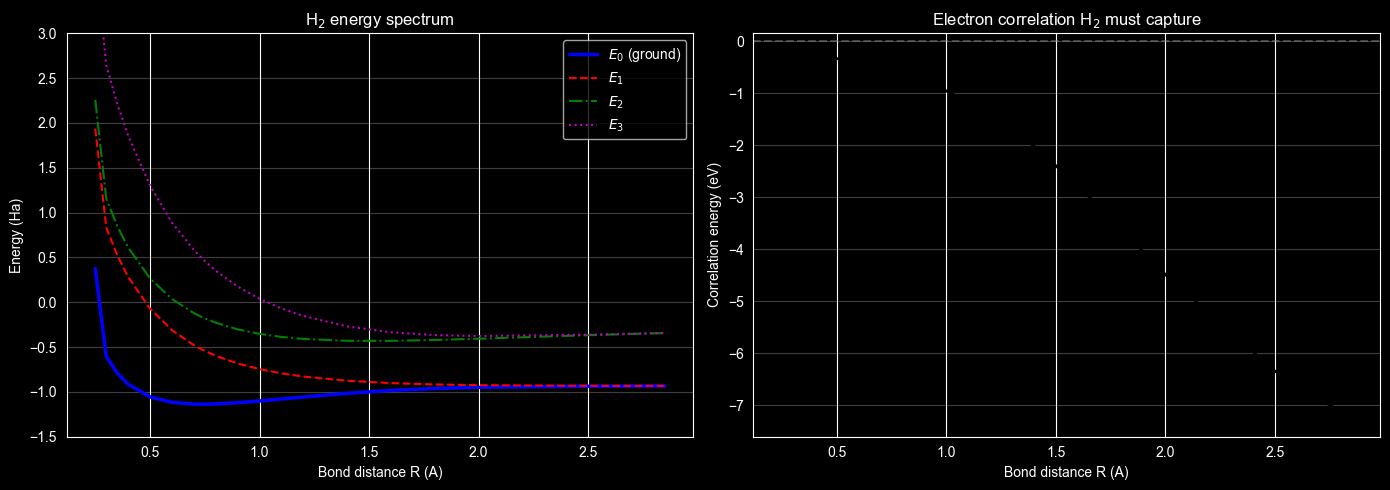

Correlation energy at equilibrium: -0.552 eV
Correlation energy at R=2.85 A:    -7.251 eV

  Correlation grows 13.1x from equilibrium to dissociation


In [4]:
# --- H₂ spectral analysis across bond distances ---
Rs, E0s, E1s, E2s, E3s, E_hfs = [], [], [], [], [], []
for row in H2_DATA:
    H_mat = h2_hamiltonian(row).to_matrix()
    ev = np.sort(np.linalg.eigvalsh(H_mat.real))
    Rs.append(row[0])
    E0s.append(ev[0]); E1s.append(ev[1])
    E2s.append(ev[2]); E3s.append(ev[3])
    E_hfs.append(np.real(H_mat[0, 0]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(Rs, E0s, "b-", lw=2.5, label="$E_0$ (ground)")
ax1.plot(Rs, E1s, "r--", lw=1.5, label="$E_1$")
ax1.plot(Rs, E2s, "g-.", lw=1.5, label="$E_2$")
ax1.plot(Rs, E3s, "m:", lw=1.5, label="$E_3$")
ax1.set_xlabel("Bond distance R (A)"); ax1.set_ylabel("Energy (Ha)")
ax1.set_title("H$_2$ energy spectrum"); ax1.legend()
ax1.set_ylim(-1.5, 3.0); ax1.grid(axis="y", alpha=0.25)

# Correlation energy = FCI - HF
corr = [e - h for e, h in zip(E0s, E_hfs)]
ax2.plot(Rs, np.array(corr) * 27.211, "k-", lw=2)
ax2.set_xlabel("Bond distance R (A)"); ax2.set_ylabel("Correlation energy (eV)")
ax2.set_title("Electron correlation H$_2$ must capture")
ax2.axhline(0, color="gray", ls="--", alpha=0.5)
ax2.grid(axis="y", alpha=0.25)

plt.tight_layout(); plt.savefig("spectral_analysis.png", dpi=150); plt.show()

# At dissociation, correlation is huge — HF completely fails
corr_eq = corr[Rs.index(0.735)] * 27.211
corr_dis = corr[-1] * 27.211
print(f"Correlation energy at equilibrium: {corr_eq:.3f} eV")
print(f"Correlation energy at R=2.85 A:    {corr_dis:.3f} eV")
assert abs(corr_dis) > abs(corr_eq) * 5, "Dissociation should have much larger correlation"
print(f"\n  Correlation grows {abs(corr_dis/corr_eq):.1f}x from equilibrium to dissociation")

## Part IV — Hydrogen Dissociation Curve

The **H₂ dissociation curve** is the canonical VQE benchmark.  We compare
three levels of theory:

| Method | Description | Exact at dissociation? |
|--------|-------------|----------------------|
| **Hartree–Fock** | Single determinant $\|00\rangle$ | ✗ — huge error at large $R$ |
| **VQE (UCC)** | $R_y(\theta)\|0\rangle \otimes \text{CNOT}$ | ✓ — captures correlation |
| **FCI** | Exact diagonalisation | ✓ — reference |

The **unitary coupled-cluster (UCC)** ansatz with a single double-excitation
parameter creates the state

$$|\psi(\theta)\rangle = \cos\!\tfrac{\theta}{2}\,|00\rangle
                        + \sin\!\tfrac{\theta}{2}\,|11\rangle$$

which spans the closed-shell block exactly. VQE optimises $\theta$ to minimise
$\langle\psi(\theta)|H(R)|\psi(\theta)\rangle$ at each bond distance.

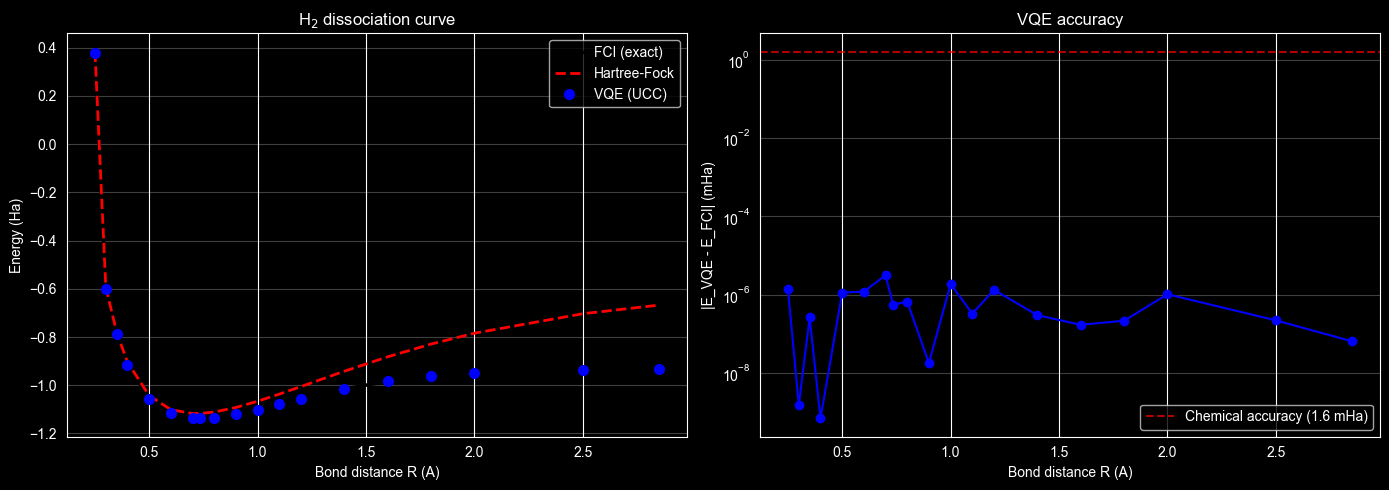

VQE max error: 0.0000 mHa
Optimal theta at R=0.735 A: -0.2235 rad
Optimal theta at R=2.85 A:  -1.4707 rad
  (theta -> pi/2 at dissociation => equal superposition |00>+|11>)


In [5]:
# --- VQE H₂ dissociation curve ---
def vqe_ucc_energy(theta, H_op):
    qc = QuantumCircuit(2)
    qc.ry(theta[0], 0)
    qc.cx(0, 1)
    return float(np.real(Statevector(qc).expectation_value(H_op)))

R_list, E_fci, E_hf_list, E_vqe, theta_opt = [], [], [], [], []

for row in H2_DATA:
    R = row[0]
    H_op = h2_hamiltonian(row)
    H_mat = H_op.to_matrix()

    e_exact = np.min(np.linalg.eigvalsh(H_mat.real))
    e_hf = float(np.real(H_mat[0, 0]))

    # VQE with warm start from previous theta
    x0 = [theta_opt[-1]] if theta_opt else [0.01]
    res = minimize(vqe_ucc_energy, x0=x0, args=(H_op,), method="COBYLA",
                   options={"maxiter": 200, "rhobeg": 0.5})

    R_list.append(R); E_fci.append(e_exact)
    E_hf_list.append(e_hf); E_vqe.append(res.fun)
    theta_opt.append(res.x[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(R_list, E_fci, "k-", lw=2.5, label="FCI (exact)")
ax1.plot(R_list, E_hf_list, "r--", lw=2, label="Hartree-Fock")
ax1.plot(R_list, E_vqe, "bo", ms=7, label="VQE (UCC)", zorder=5)
ax1.set_xlabel("Bond distance R (A)"); ax1.set_ylabel("Energy (Ha)")
ax1.set_title("H$_2$ dissociation curve"); ax1.legend()
ax1.grid(axis="y", alpha=0.25)

# VQE error
vqe_err = [abs(v - f) * 1000 for v, f in zip(E_vqe, E_fci)]  # mHa
ax2.semilogy(R_list, vqe_err, "bo-", lw=1.5)
ax2.set_xlabel("Bond distance R (A)"); ax2.set_ylabel("|E_VQE - E_FCI| (mHa)")
ax2.set_title("VQE accuracy"); ax2.axhline(1.6, color="red", ls="--",
    alpha=0.7, label="Chemical accuracy (1.6 mHa)")
ax2.legend(); ax2.grid(axis="y", alpha=0.25)

plt.tight_layout(); plt.savefig("h2_dissociation.png", dpi=150); plt.show()

max_err = max(vqe_err)
print(f"VQE max error: {max_err:.4f} mHa")
assert max_err < 1.0, f"VQE error too large: {max_err} mHa"

# Optimal angle at dissociation
print(f"Optimal theta at R=0.735 A: {theta_opt[R_list.index(0.735)]:.4f} rad")
print(f"Optimal theta at R=2.85 A:  {theta_opt[-1]:.4f} rad")
print(f"  (theta -> pi/2 at dissociation => equal superposition |00>+|11>)")

## Part V — The Ansatz Zoo

The choice of parameterised circuit — the **ansatz** — determines whether VQE
can reach the ground state and how efficiently it converges.

### Hardware-Efficient Ansatz (HEA)

Generic layers of single-qubit rotations ($R_y, R_z$) and entangling gates
(CNOT).  **Pro**: minimal circuit depth, hardware-native.  **Con**: no chemical
structure; prone to barren plateaus at scale.

### Unitary Coupled Cluster (UCC)

Inspired by classical coupled-cluster theory:
$|\psi\rangle = e^{T - T^\dagger}|\Phi_0\rangle$ where $T$ generates single
and double excitations.  **Pro**: chemically motivated, compact for small
molecules.  **Con**: deep circuits for large $T$.

### ADAPT-VQE

Iteratively grows the ansatz by selecting the operator with the **largest
gradient** from a pool.  **Pro**: automatically balances expressibility and
depth.  **Con**: requires many gradient evaluations per iteration.

### Hamiltonian Variational Ansatz (HVA)

Uses the Hamiltonian's own terms as generators:
$|\psi\rangle = \prod_l e^{-i\theta_l H_k}|\Phi_0\rangle$.
**Pro**: respects problem symmetry, resists barren plateaus.
**Con**: circuit depth scales with Hamiltonian complexity.

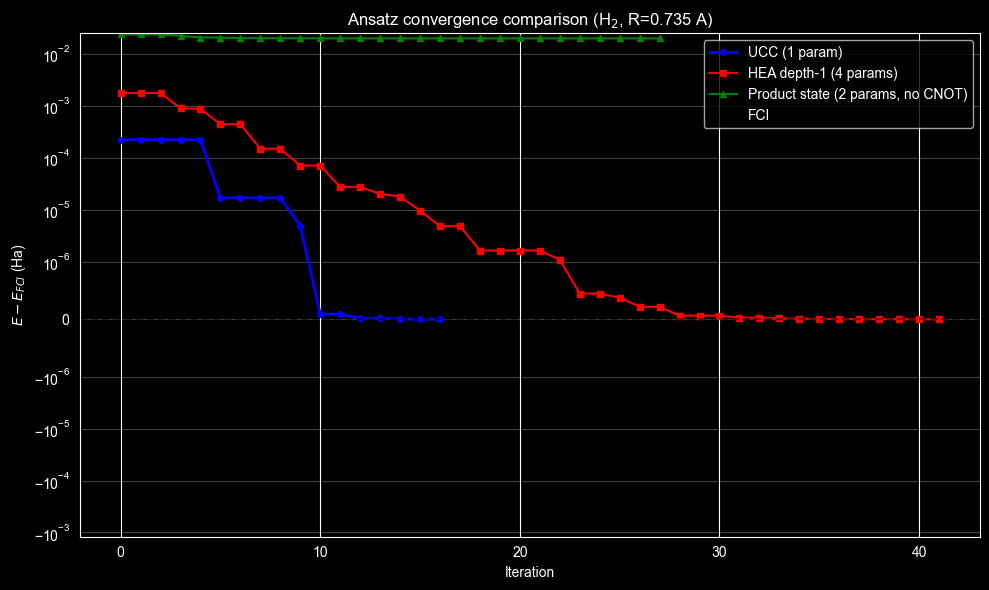

UCC final error:     7.41e-10 Ha
HEA final error:     3.20e-10 Ha
Product final error: 0.020300 Ha  (stuck at HF!)

  Entanglement is essential: product ansatz cannot capture correlation!


In [6]:
# --- Ansatz comparison on H₂ at equilibrium ---
H_eq_op = h2_hamiltonian(H2_DATA[7])  # R = 0.735 A
E_target = np.min(np.linalg.eigvalsh(H_eq_op.to_matrix().real))

def track_convergence(fun, x0, args, method="COBYLA", maxiter=80):
    history = []
    def callback_wrap(params, *a):
        qc_args = args
        history.append(fun(params, *qc_args))
    # Run with small steps for tracking
    res = minimize(fun, x0=x0, args=args, method=method,
                   options={"maxiter": maxiter, "rhobeg": 0.3},
                   callback=callback_wrap)
    history.append(res.fun)
    return history, res

# 1. UCC (1 param): Ry + CNOT
def ucc_energy(p, H_op):
    qc = QuantumCircuit(2)
    qc.ry(p[0], 0); qc.cx(0, 1)
    return float(np.real(Statevector(qc).expectation_value(H_op)))

# 2. HEA depth-1 (4 params): Ry-Ry-CNOT-Ry-Ry
def hea1_energy(p, H_op):
    qc = QuantumCircuit(2)
    qc.ry(p[0], 0); qc.ry(p[1], 1); qc.cx(0, 1)
    qc.ry(p[2], 0); qc.ry(p[3], 1)
    return float(np.real(Statevector(qc).expectation_value(H_op)))

# 3. Product state (2 params): Ry-Ry, no entanglement
def product_energy(p, H_op):
    qc = QuantumCircuit(2)
    qc.ry(p[0], 0); qc.ry(p[1], 1)
    return float(np.real(Statevector(qc).expectation_value(H_op)))

np.random.seed(SEED)
h_ucc, _ = track_convergence(ucc_energy, [0.1], (H_eq_op,))
h_hea, _ = track_convergence(hea1_energy, [0.1]*4, (H_eq_op,))
h_prd, _ = track_convergence(product_energy, [0.1]*2, (H_eq_op,))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(h_ucc)), np.array(h_ucc) - E_target, "b-o", ms=4,
        label="UCC (1 param)", lw=2)
ax.plot(range(len(h_hea)), np.array(h_hea) - E_target, "r-s", ms=4,
        label="HEA depth-1 (4 params)", lw=1.5)
ax.plot(range(len(h_prd)), np.array(h_prd) - E_target, "g-^", ms=4,
        label="Product state (2 params, no CNOT)", lw=1.5)
ax.axhline(0, color="k", ls="--", alpha=0.5, label="FCI")
ax.set_xlabel("Iteration"); ax.set_ylabel("$E - E_{FCI}$ (Ha)")
ax.set_title("Ansatz convergence comparison (H$_2$, R=0.735 A)")
ax.set_yscale("symlog", linthresh=1e-6)
ax.legend(); ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.savefig("ansatz_comparison.png", dpi=150); plt.show()

print(f"UCC final error:     {abs(h_ucc[-1] - E_target):.2e} Ha")
print(f"HEA final error:     {abs(h_hea[-1] - E_target):.2e} Ha")
print(f"Product final error: {abs(h_prd[-1] - E_target):.6f} Ha  (stuck at HF!)")

assert abs(h_ucc[-1] - E_target) < 1e-4, "UCC should reach FCI"
assert abs(h_hea[-1] - E_target) < 1e-4, "HEA should reach FCI"
assert abs(h_prd[-1] - E_target) > 0.01, "Product state cannot reach FCI"
print("\n  Entanglement is essential: product ansatz cannot capture correlation!")

## Part VI — Optimizer Arena

VQE's classical loop demands an optimizer that handles:

- **Noisy cost function** (shot noise in real hardware).
- **Non-convex landscape** (local minima, saddle points).
- **Limited budget** (each evaluation = QPU time).

| Optimizer | Type | Gradient? | Shot-noise tolerance |
|-----------|------|-----------|---------------------|
| **COBYLA** | Trust-region | No | Moderate |
| **Nelder–Mead** | Simplex | No | Moderate |
| **L-BFGS-B** | Quasi-Newton | Yes (FD) | Poor |
| **SPSA** | Stochastic | Approx (2 evals) | Excellent |

We compare all four on the HEA depth-1 ansatz for H₂.

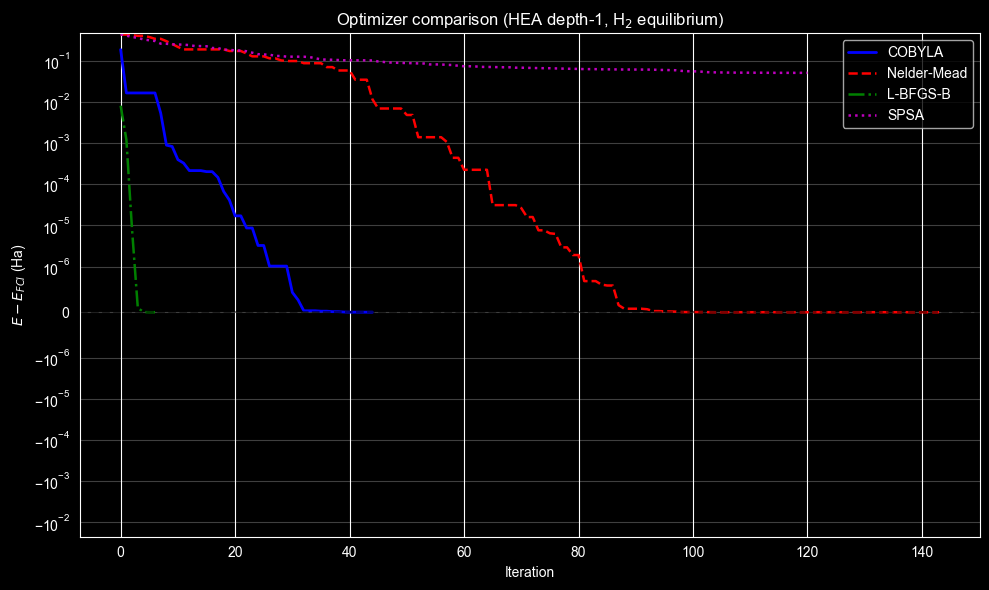

  COBYLA      : final error = 1.11e-09 Ha  (45 iters)
  Nelder-Mead : final error = 1.04e-14 Ha  (144 iters)
  L-BFGS-B    : final error = 6.00e-15 Ha  (7 iters)
  SPSA        : final error = 5.14e-02 Ha  (121 iters)

  Best optimizer: L-BFGS-B


In [7]:
# --- Optimizer comparison on H₂ (HEA depth-1 ansatz) ---
np.random.seed(SEED)
x0_opt = np.array([0.5, 0.5, 0.5, 0.5])

optimizers = {
    "COBYLA":      {"method": "COBYLA",      "options": {"maxiter": 120, "rhobeg": 0.4}},
    "Nelder-Mead": {"method": "Nelder-Mead", "options": {"maxiter": 200, "xatol": 1e-6}},
    "L-BFGS-B":    {"method": "L-BFGS-B",    "options": {"maxiter": 100}},
}

opt_histories = {}
for name, opts in optimizers.items():
    history = []
    def cb(p, hist=history):
        hist.append(hea1_energy(p, H_eq_op))
    res = minimize(hea1_energy, x0=x0_opt.copy(), args=(H_eq_op,),
                   callback=cb, **opts)
    history.append(res.fun)
    opt_histories[name] = history

# SPSA (manual implementation)
def spsa_optimize(fun, x0, args, n_iter=120, a=0.1, c=0.1, alpha=0.602, gamma=0.101):
    x = x0.copy()
    history = [fun(x, *args)]
    for k in range(1, n_iter + 1):
        ak = a / (k + 1) ** alpha
        ck = c / (k + 1) ** gamma
        delta = np.random.choice([-1, 1], size=len(x))
        f_plus = fun(x + ck * delta, *args)
        f_minus = fun(x - ck * delta, *args)
        g_hat = (f_plus - f_minus) / (2 * ck * delta)
        x = x - ak * g_hat
        history.append(fun(x, *args))
    return history

np.random.seed(SEED)
opt_histories["SPSA"] = spsa_optimize(hea1_energy, x0_opt.copy(), (H_eq_op,))

fig, ax = plt.subplots(figsize=(10, 6))
styles = {"COBYLA": ("b-", 2), "Nelder-Mead": ("r--", 1.8),
          "L-BFGS-B": ("g-.", 1.8), "SPSA": ("m:", 1.8)}
for name, hist in opt_histories.items():
    ls, lw = styles[name]
    ax.plot(np.array(hist) - E_target, ls, lw=lw, label=name)

ax.axhline(0, color="k", ls="--", alpha=0.5)
ax.set_xlabel("Iteration"); ax.set_ylabel("$E - E_{FCI}$ (Ha)")
ax.set_title("Optimizer comparison (HEA depth-1, H$_2$ equilibrium)")
ax.set_yscale("symlog", linthresh=1e-6); ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.savefig("optimizer_comparison.png", dpi=150); plt.show()

for name, hist in opt_histories.items():
    final_err = abs(hist[-1] - E_target)
    print(f"  {name:12s}: final error = {final_err:.2e} Ha  ({len(hist)} iters)")

best = min(opt_histories, key=lambda n: abs(opt_histories[n][-1] - E_target))
assert abs(opt_histories[best][-1] - E_target) < 0.01
print(f"\n  Best optimizer: {best}")

## Part VII — The Barren Plateau Problem

A fundamental obstacle for VQE at scale: **barren plateaus** (McClean et al.,
Nature Communications 2018).

For deep, randomly-initialised hardware-efficient ansätze, the variance of
the cost-function gradient decays **exponentially** with qubit count:

$$
\text{Var}\!\left[\frac{\partial \langle H \rangle}{\partial \theta_k}\right]
\sim \mathcal{O}(2^{-n})
$$

This means the gradient signal vanishes in an exponentially large flat
landscape — the optimizer sees essentially zero gradient everywhere and cannot
find the minimum.

**Mitigations:**

| Strategy | Mechanism |
|----------|-----------|
| Structured ansätze (HVA) | Preserve symmetry → structured landscape |
| Local cost functions | $\text{Var} \sim \mathcal{O}(\text{poly}^{-1}(n))$ |
| Layer-wise training | Train one layer at a time |
| Parameter correlation | Initialise near identity circuit |
| ADAPT-VQE | Grows circuit incrementally |

  n=2 qubits, 2 layers: Var[dE/dtheta] = 0.268883
  n=3 qubits, 3 layers: Var[dE/dtheta] = 0.160924
  n=4 qubits, 4 layers: Var[dE/dtheta] = 0.081787
  n=5 qubits, 5 layers: Var[dE/dtheta] = 0.060510
  n=6 qubits, 6 layers: Var[dE/dtheta] = 0.036234
  n=7 qubits, 7 layers: Var[dE/dtheta] = 0.017691


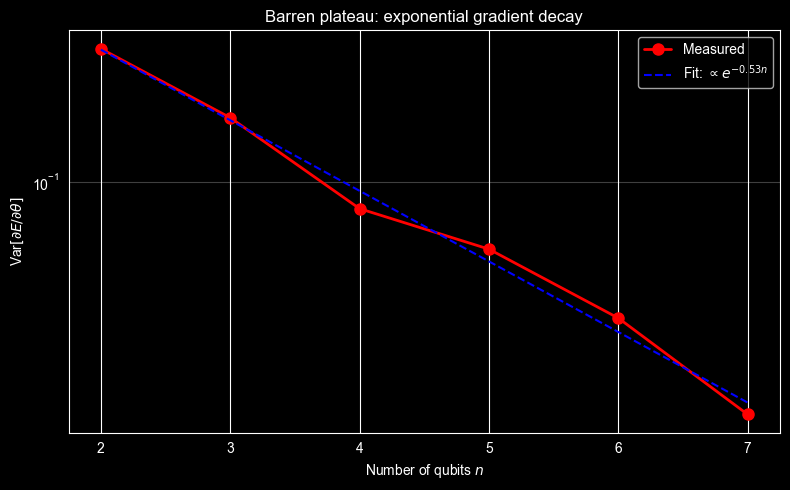


Exponential decay rate: -0.525 per qubit
Theoretical (Haar random): -ln(2) = -0.693

  Confirmed: gradient variance decays exponentially with qubit count!


In [8]:
# --- Barren plateau: gradient variance vs qubit count ---
np.random.seed(SEED)

def gradient_variance(n_qubits, n_layers, n_samples=300):
    # Cost function: Z on first qubit (global observable)
    pauli_str = "I" * (n_qubits - 1) + "Z"
    H_bp = SparsePauliOp.from_list([(pauli_str, 1.0)])

    grads = []
    for _ in range(n_samples):
        n_params = n_qubits * n_layers * 2
        params = np.random.uniform(0, 2 * pi, n_params)

        def build_qc(p):
            qc = QuantumCircuit(n_qubits)
            idx = 0
            for _ in range(n_layers):
                for q in range(n_qubits):
                    qc.ry(p[idx], q); idx += 1
                    qc.rz(p[idx], q); idx += 1
                for q in range(n_qubits - 1):
                    qc.cx(q, q + 1)
            return qc

        p_plus = params.copy(); p_plus[0] += pi / 2
        p_minus = params.copy(); p_minus[0] -= pi / 2
        E_p = float(np.real(Statevector(build_qc(p_plus)).expectation_value(H_bp)))
        E_m = float(np.real(Statevector(build_qc(p_minus)).expectation_value(H_bp)))
        grads.append((E_p - E_m) / 2)

    return np.var(grads)

qubit_range = [2, 3, 4, 5, 6, 7]
variances = []
for n in qubit_range:
    v = gradient_variance(n, n_layers=n, n_samples=300)
    variances.append(v)
    print(f"  n={n} qubits, {n} layers: Var[dE/dtheta] = {v:.6f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(qubit_range, variances, "ro-", ms=8, lw=2, label="Measured")
# Fit exponential
coeffs = np.polyfit(qubit_range, np.log(variances), 1)
fit_line = np.exp(coeffs[1]) * np.exp(coeffs[0] * np.array(qubit_range))
ax.semilogy(qubit_range, fit_line, "b--", lw=1.5,
            label=f"Fit: $\\propto e^{{{coeffs[0]:.2f} n}}$")
ax.set_xlabel("Number of qubits $n$"); ax.set_ylabel(r"Var$[\partial E / \partial \theta]$")
ax.set_title("Barren plateau: exponential gradient decay")
ax.legend(); ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.savefig("barren_plateau.png", dpi=150); plt.show()

decay_rate = coeffs[0]
print(f"\nExponential decay rate: {decay_rate:.3f} per qubit")
print(f"Theoretical (Haar random): -ln(2) = {-np.log(2):.3f}")
assert decay_rate < -0.3, f"Should show exponential decay: {decay_rate}"
print(f"\n  Confirmed: gradient variance decays exponentially with qubit count!")

## Part VIII — Measurement Strategies

VQE estimates $\langle H \rangle = \sum_k c_k \langle P_k \rangle$ by
measuring each Pauli term $P_k$ independently.  The total variance is

$$
\text{Var}[\hat{E}] = \sum_k \frac{c_k^2\, \text{Var}[\hat{P}_k]}{N_k}
$$

where $N_k$ shots are allocated to term $k$.

**Grouping strategies** reduce the measurement overhead:

- **Qubit-wise commuting (QWC)**: Paulis that commute on every qubit can
  share a single measurement basis.
- **General commutativity**: broader groups, but requires entangling
  measurement circuits.
- **Classical shadows**: randomised measurements that estimate all terms
  simultaneously.

For H₂ the 5-term Hamiltonian groups into just **2 measurement bases**:
$\{II, IZ, ZI, ZZ\}$ (computational basis) and $\{YY\}$ (Y-basis on both qubits).

H2 Hamiltonian: 5 Pauli terms
QWC groups: 2
  Group 1: ['II', 'IZ', 'ZI', 'ZZ']
  Group 2: ['YY']


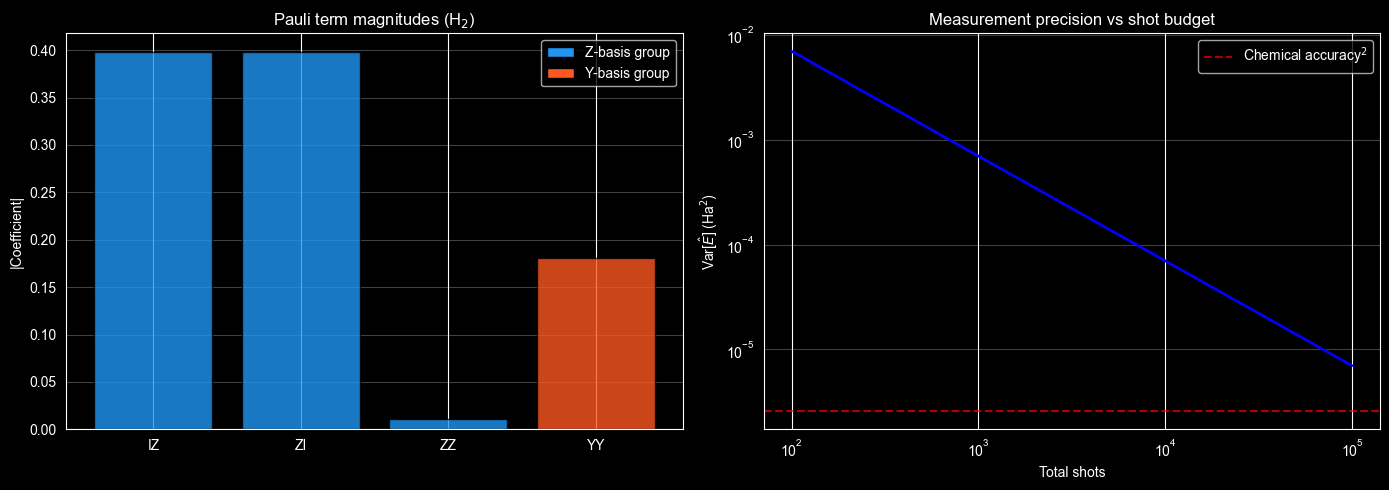


Shots for chemical accuracy (1.6 mHa):
  ~ 272,940 total shots across 2 measurement bases

  H2 needs only 2 measurement bases (compact!)


In [9]:
# --- Pauli grouping and shot budget for H₂ ---

def qwc_compatible(p1, p2):
    for a, b in zip(p1, p2):
        if a != "I" and b != "I" and a != b:
            return False
    return True

def group_paulis(terms):
    groups = []
    for term in terms:
        placed = False
        for g in groups:
            if all(qwc_compatible(term, t) for t in g):
                g.append(term); placed = True; break
        if not placed:
            groups.append([term])
    return groups

h2_terms = ["II", "IZ", "ZI", "ZZ", "YY"]
h2_coeffs = dict(zip(h2_terms,
    [H2_DATA[7][1], H2_DATA[7][2], H2_DATA[7][3], H2_DATA[7][4], H2_DATA[7][5]]))

groups = group_paulis(h2_terms)
print(f"H2 Hamiltonian: {len(h2_terms)} Pauli terms")
print(f"QWC groups: {len(groups)}")
for i, g in enumerate(groups):
    print(f"  Group {i+1}: {g}")

# Shot budget analysis: variance vs total shots
# For equal allocation: Var[E] = sum(c_k^2 * Var[P_k]) / N_per_group
# Var[P_k] <= 1 for any Pauli observable

total_shots_range = np.logspace(2, 5, 50).astype(int)
n_groups_meas = sum(1 for g in groups if any(t != "II" for t in g))
variance_equal = []
for N_total in total_shots_range:
    N_per = N_total // max(n_groups_meas, 1)
    var_E = sum(h2_coeffs[t]**2 / max(N_per, 1)
                for t in h2_terms if t != "II")
    variance_equal.append(var_E)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Pauli coefficient magnitudes
terms_plot = [t for t in h2_terms if t != "II"]
coeffs_plot = [abs(h2_coeffs[t]) for t in terms_plot]
colors = ["#2196F3" if t in groups[0] else "#FF5722" for t in terms_plot]
ax1.bar(terms_plot, coeffs_plot, color=colors, edgecolor="black", alpha=0.8)
ax1.set_ylabel("|Coefficient|"); ax1.set_title("Pauli term magnitudes (H$_2$)")
ax1.grid(axis="y", alpha=0.25)
ax1.legend(handles=[
    plt.Rectangle((0,0),1,1, fc="#2196F3", ec="black", label="Z-basis group"),
    plt.Rectangle((0,0),1,1, fc="#FF5722", ec="black", label="Y-basis group"),
])

# Right: shot budget
ax2.loglog(total_shots_range, variance_equal, "b-", lw=2)
ax2.axhline(0.0016**2, color="r", ls="--", alpha=0.7,
            label="Chemical accuracy$^2$")
ax2.set_xlabel("Total shots"); ax2.set_ylabel("Var[$\\hat{E}$] (Ha$^2$)")
ax2.set_title("Measurement precision vs shot budget")
ax2.legend(); ax2.grid(axis="y", alpha=0.25)

plt.tight_layout(); plt.savefig("measurement_budget.png", dpi=150); plt.show()

# Chemical accuracy needs
chem_acc = 0.0016  # Ha
N_needed = int(sum(h2_coeffs[t]**2 for t in h2_terms if t != "II")
               / chem_acc**2) * n_groups_meas
print(f"\nShots for chemical accuracy ({chem_acc*1000:.1f} mHa):")
print(f"  ~ {N_needed:,} total shots across {n_groups_meas} measurement bases")
assert n_groups_meas == 2, "H2 should need 2 measurement bases"
print(f"\n  H2 needs only {n_groups_meas} measurement bases (compact!)")

## Part IX — VQE in Practice

### Landmark Experiments

| Year | Group | Molecule | Qubits | Hardware | Key result |
|------|-------|----------|--------|----------|------------|
| 2014 | Peruzzo et al. | He-H⁺ | 2 | Photonic | First VQE experiment |
| 2017 | Kandala et al. | LiH, BeH₂ | 6 | IBM (supercond.) | Largest VQE molecule at time |
| 2019 | Nam et al. | H₂O | 4 | IonQ (trapped ion) | Water on quantum hardware |
| 2020 | Arute et al. | H₁₂ chain, diazene | 12 | Google Sycamore | Hartree–Fock on 12 qubits |
| 2023 | Kim et al. | Ising (127 q.) | 127 | IBM Eagle | Utility-scale error mitigation |
| 2024 | Robledo-Moreno et al. | N₂ | 12 | Supercond. | Contextual subspace VQE |
| 2025 | Shlosberg et al. | Various | — | Theory | SHARC-VQE: errors 20→5% |

### Key Advances

- **ADAPT-VQE** (Grimsley et al., 2019): automated ansatz construction
  reduced H₂/LiH circuits by 50–80% vs fixed UCCSD.
- **Error mitigation** (ZNE, PEC, symmetry verification): pushed useful
  results beyond raw hardware noise.
- **Measurement reduction** (grouping, classical shadows, derandomisation):
  cut shot budgets by 3–10×.
- **Parameter-shift gradients** → gradient-based VQE now standard.

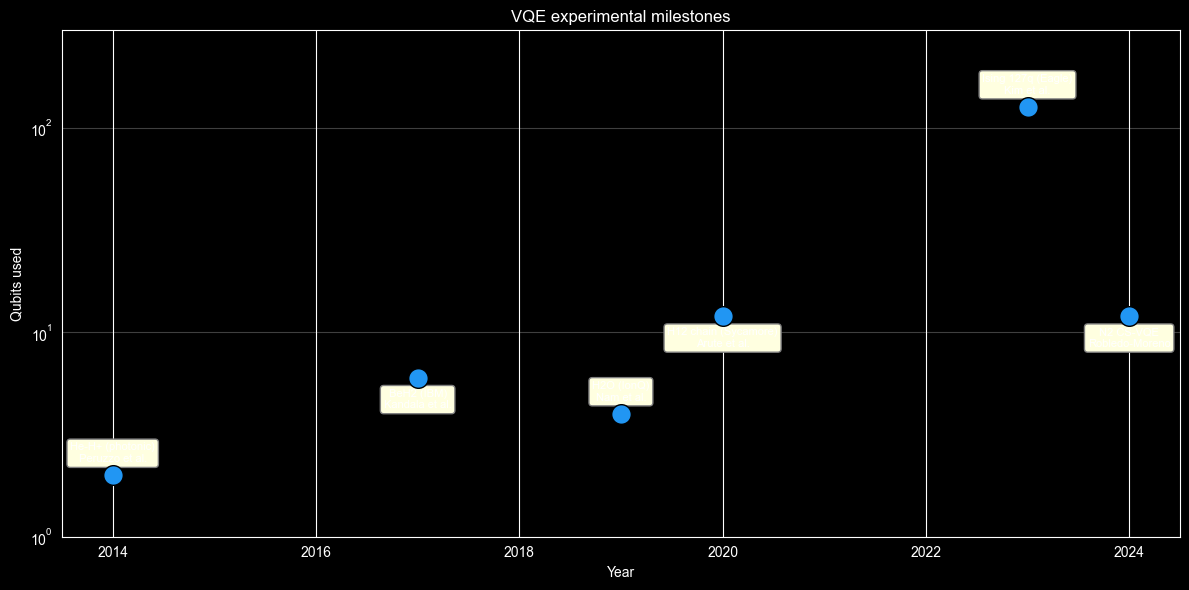

VQE has progressed from 2 photonic qubits (2014) to 127 superconducting qubits (2023)
Molecular size: He-H+ -> BeH2 -> H2O -> H12 -> N2 (with error mitigation)


In [10]:
# --- VQE milestones timeline ---
milestones = [
    (2014, 2,  "He-H+ (photonic)\nPeruzzo et al."),
    (2017, 6,  "BeH2 (IBM)\nKandala et al."),
    (2019, 4,  "H2O (IonQ)\nNam et al."),
    (2020, 12, "H12 chain (Sycamore)\nArute et al."),
    (2023, 127, "Ising 127q (Eagle)\nKim et al."),
    (2024, 12, "N2 CS-VQE\nRobledo-Moreno"),
]

years = [m[0] for m in milestones]
qubits = [m[1] for m in milestones]
labels = [m[2] for m in milestones]

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(years, qubits, s=200, c="#2196F3", edgecolor="black", zorder=5)

for i, (y, q, lab) in enumerate(milestones):
    va = "bottom" if i % 2 == 0 else "top"
    offset = 8 if i % 2 == 0 else -8
    ax.annotate(lab, (y, q), textcoords="offset points",
                xytext=(0, offset), ha="center", va=va, fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))

ax.set_xlabel("Year"); ax.set_ylabel("Qubits used")
ax.set_title("VQE experimental milestones")
ax.set_yscale("log"); ax.set_ylim(1, 300)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.savefig("vqe_milestones.png", dpi=150); plt.show()

print("VQE has progressed from 2 photonic qubits (2014) to 127 superconducting qubits (2023)")
print("Molecular size: He-H+ -> BeH2 -> H2O -> H12 -> N2 (with error mitigation)")

## Part X — Frontiers & Open Challenges

### Near-Term Priorities

1. **Scaling the ansatz**: ADAPT-VQE and tensor-network ansätze aim to keep
   circuit depth manageable for 50–100 qubit molecules.
2. **Error mitigation at scale**: zero-noise extrapolation (ZNE),
   probabilistic error cancellation (PEC), and symmetry verification push
   useful chemistry beyond raw hardware noise floors.
3. **Measurement efficiency**: classical shadows and informationally complete
   POVMs reduce the exponential shot overhead for large Hamiltonians.
4. **Excited states**: VQD (Variational Quantum Deflation) and subspace
   methods extend VQE to photochemistry and reaction dynamics.

### The Quantum Advantage Horizon

Current VQE demonstrations match or slightly exceed classical methods for
molecules with ≤ 20 orbitals.  The crossover to genuine **quantum advantage**
is expected in the 50–200 logical-qubit regime for strongly correlated systems
(transition metal catalysts, enzymatic active sites).

### Connection to Fault-Tolerant Era

As error-corrected hardware matures, VQE's variational approach will likely
be supplanted by **quantum phase estimation (QPE)** for ground states and
**quantum signal processing** for dynamics — but VQE remains the bridge
between NISQ and fault-tolerant quantum chemistry.

In [11]:
# --- Summary validation ---
print("=" * 60)
print("  401 — VQE Deep Dive: Summary Validation")
print("=" * 60)

# 1. Parameter shift rule
p_test = np.array([1.0, 0.5, 0.3])
g_psr = psr_gradient(p_test, 0)
g_fd = fd_gradient(p_test, 0, eps=1e-7)
assert abs(g_psr - g_fd) < 1e-4, "PSR failed"
print(f"  [PASS] Parameter shift rule exact (err={abs(g_psr-g_fd):.1e})")

# 2. H2 FCI at equilibrium
H_eq_check = h2_hamiltonian(H2_DATA[7])
E_fci_check = np.min(np.linalg.eigvalsh(H_eq_check.to_matrix().real))
assert abs(E_fci_check - (-1.1373)) < 0.001
print(f"  [PASS] H2 FCI = {E_fci_check:.4f} Ha (expected: -1.137 Ha)")

# 3. VQE recovers FCI
res_check = minimize(vqe_ucc_energy, [0.1], args=(H_eq_check,), method="COBYLA")
assert abs(res_check.fun - E_fci_check) < 1e-3
print(f"  [PASS] VQE(UCC) = {res_check.fun:.4f} Ha (FCI match)")

# 4. Product state fails
res_prod = minimize(product_energy, [0.1, 0.1], args=(H_eq_check,), method="COBYLA")
assert abs(res_prod.fun - E_fci_check) > 0.01
print(f"  [PASS] Product state stuck at HF ({res_prod.fun:.4f} Ha)")

# 5. Barren plateau shows decay
assert variances[-1] < variances[0] / 3
print(f"  [PASS] Gradient variance decays: {variances[0]:.4f} -> {variances[-1]:.4f}")

# 6. Measurement groups
assert len(groups) == 2
print(f"  [PASS] H2 needs {len(groups)} QWC groups")

print("=" * 60)
print("  All validations passed!")
print("=" * 60)

  401 — VQE Deep Dive: Summary Validation
  [PASS] Parameter shift rule exact (err=1.4e-09)
  [PASS] H2 FCI = -1.1373 Ha (expected: -1.137 Ha)
  [PASS] VQE(UCC) = -1.1373 Ha (FCI match)
  [PASS] Product state stuck at HF (-1.1170 Ha)
  [PASS] Gradient variance decays: 0.2689 -> 0.0177
  [PASS] H2 needs 2 QWC groups
  All validations passed!


## Key Takeaways

| # | Concept | Insight |
|---|---------|---------|
| 1 | **Parameter shift rule** | Exact gradients at cost of 2 circuit evaluations per parameter |
| 2 | **Molecular Hamiltonians** | Molecules → second quantisation → JW mapping → Pauli sums |
| 3 | **H₂ dissociation** | VQE captures correlation that Hartree–Fock misses at bond-breaking |
| 4 | **Ansatz design** | Entanglement is essential; UCC is exact for H₂; HEA is general but risky |
| 5 | **Optimizer choice** | COBYLA robust for NISQ; SPSA best for shot noise; L-BFGS-B when gradients are clean |
| 6 | **Barren plateaus** | Gradient variance $\sim 2^{-n}$ for deep random circuits — the key scaling obstacle |
| 7 | **Measurement overhead** | Pauli grouping + shot allocation → manageable budgets for small molecules |
| 8 | **State of the art** | 2–127 qubits demonstrated; advantage horizon at 50–200 logical qubits |
| 9 | **Path forward** | ADAPT-VQE + error mitigation + classical shadows → near-term utility |

## Cross-references

| Topic | Notebook |
|-------|----------|
| Superposition, Bloch sphere | `100_quantum_superposition` |
| Unitarity, gates | `102_quantum_unitary` |
| Hamiltonians, Ising model | `200_quantum_hamiltonian` |
| QAOA, MaxCut | `201_quantum_qaoa` |
| QUBO ↔ Ising | `202_quantum_qubo` |
| Trotter–Suzuki, Jordan–Wigner, VQE intro | `400_quantum_simulation` |
| **VQE deep dive** | **this notebook** |
| VQE for chemistry (coming next) | `402_quantum_chemistry` |